# 🎬 Netflix Movies and TV Shows — Data Visualization and Analysis

**Author:** Om Dipak Patil
**Dataset:** Netflix Titles Dataset (CSV)  
**Tools:** Python, Pandas, NumPy, Matplotlib, Seaborn, WordCloud

---

## 1. Introduction

### What is Netflix?

**Netflix** is the world's largest subscription-based video streaming platform, founded in 1997. As of 2023, it has over 230 million subscribers in more than 190 countries. It offers a vast library of movies, TV shows, documentaries, and original content.

### Why Analyze Streaming Platform Data?

Analyzing Netflix data helps us understand:
- **Content strategy** — Is Netflix investing more in movies or TV shows?
- **Geographic trends** — Which countries produce the most content?
- **Growth patterns** — How has the content library expanded over time?
- **Audience targeting** — What content ratings dominate the platform?
- **Industry insights** — Which genres and directors are most represented?

### What Insights Do We Want to Discover?

- Does Netflix have more **Movies or TV Shows**?
- Which **countries** produce the most Netflix content?
- How has Netflix content **grown over time**?
- What are the most common **content ratings**?
- Which **genres and directors** dominate the platform?

### Dataset Column Descriptions

| Column | Description |
|---|---|
| **show_id** | Unique identifier for each title |
| **type** | Content type — Movie or TV Show |
| **title** | Name of the movie or TV show |
| **director** | Director(s) of the content |
| **cast** | Main cast members |
| **country** | Country where content was produced |
| **date_added** | Date the content was added to Netflix |
| **release_year** | Year the content was originally released |
| **rating** | Content rating (TV-MA, PG-13, R, etc.) |
| **duration** | Duration in minutes (Movies) or seasons (TV Shows) |

---

## 2. Import Libraries

We import all the required libraries for data loading, cleaning, and visualization. We use `seaborn` and `matplotlib` for static plots and `wordcloud` for text-based visuals.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from wordcloud import WordCloud
import warnings
warnings.filterwarnings('ignore')

# Set global plot style
sns.set(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 120

print(f"NumPy version    : {np.__version__}")
print(f"Pandas version   : {pd.__version__}")
print("Libraries imported successfully! ✅")

NumPy version    : 2.3.5
Pandas version   : 2.3.3
Libraries imported successfully! ✅


---

## 3. Load the Dataset

We load the Netflix dataset from the provided CSV file using Pandas and inspect its structure.

In [2]:
df = pd.read_csv('netflix_titles.csv')

print("=" * 55)
print("First 5 Rows:")
print("=" * 55)
print(df.head())

print(f"\nDataset Shape  : {df.shape}")
print(f"Columns        : {list(df.columns)}")
print("\nData Types:")
print(df.dtypes)

First 5 Rows:
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24

---

## 4. Data Cleaning

Good analysis starts with clean data. We perform the following steps:
- **Check and handle missing values** — fill with 'Unknown' for categorical columns
- **Convert `date_added`** to datetime format for time-based analysis
- **Extract `year_added`** as a new column for trend analysis
- **Check duplicates** to ensure each title is counted once
- **Summary statistics** for a quick overview

In [3]:
print("Missing Values Before Cleaning:")
print(df.isnull().sum())
print(f"\nDuplicate Rows: {df.duplicated().sum()}")

# Fill missing values
df['director'] = df['director'].fillna('Unknown')
df['cast']     = df['cast'].fillna('Unknown')
df['country']  = df['country'].fillna('Unknown')
df['rating']   = df['rating'].fillna('Not Rated')
df['duration'] = df['duration'].fillna('Unknown')

# Convert date_added to datetime and extract year
df['date_added']  = pd.to_datetime(df['date_added'], errors='coerce')
df['year_added']  = df['date_added'].dt.year
df['month_added'] = df['date_added'].dt.month

# Extract movie duration in minutes
df['duration_int'] = df['duration'].str.extract(r'(\d+)').astype(float)

print("\nMissing Values After Cleaning:")
print(df.isnull().sum())

print("\n" + "=" * 55)
print("Summary Statistics:")
print("=" * 55)
print(df.describe(include='all').T[['count','unique','top','freq']].dropna(how='all').head(12))

Missing Values Before Cleaning:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

Duplicate Rows: 0

Missing Values After Cleaning:
show_id          0
type             0
title            0
director         0
cast             0
country          0
date_added      98
release_year     0
rating           0
duration         0
listed_in        0
description      0
year_added      98
month_added     98
duration_int     3
dtype: int64

Summary Statistics:
               count unique  \
show_id         8807   8807   
type            8807      2   
title           8807   8807   
director        8807   4529   
cast            8807   7693   
country         8807    749   
date_added      8709    NaN   
release_year  8807.0    NaN   
rating          8807     18   
duration        8807   

---

## 5. Exploratory Data Analysis (EDA)

We now explore the dataset to answer five key questions:

1. Does Netflix have more **Movies or TV Shows**?
2. Which **countries** produce the most Netflix content?
3. How has Netflix content **grown over time**?
4. What are the most common **content ratings**?
5. Which **release years** dominate the platform?

In [4]:
print("Content Type Distribution:")
print(df['type'].value_counts())

print("\nTop 10 Countries:")
print(df['country'].str.split(',').explode().str.strip()
      .value_counts().head(10))

print("\nContent Added Per Year:")
print(df['year_added'].value_counts().sort_index())

Content Type Distribution:
type
Movie      6131
TV Show    2676
Name: count, dtype: int64

Top 10 Countries:
country
United States     3690
India             1046
Unknown            831
United Kingdom     806
Canada             445
France             393
Japan              318
Spain              232
South Korea        231
Germany            226
Name: count, dtype: int64

Content Added Per Year:
year_added
2008.0       2
2009.0       2
2010.0       1
2011.0      13
2012.0       3
2013.0      10
2014.0      23
2015.0      73
2016.0     418
2017.0    1164
2018.0    1625
2019.0    1999
2020.0    1878
2021.0    1498
Name: count, dtype: int64


---

## Visualization 1 — Bar Chart: Movies vs TV Shows

**Purpose:** Compare the total number of Movies and TV Shows on Netflix.

**Why effective?** A bar chart is the most intuitive way to compare two discrete categories. The height difference immediately shows which content type dominates the platform.

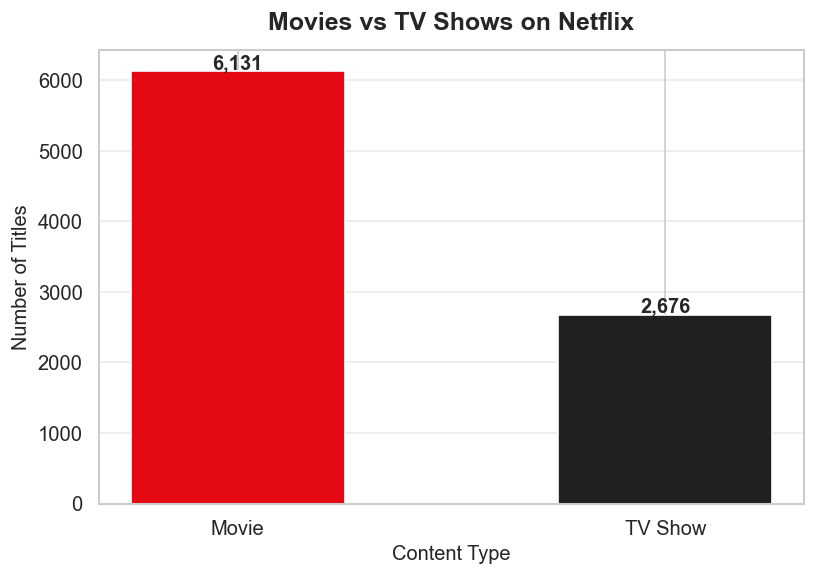


📌 Insight: Netflix has significantly more Movies than TV Shows,
   Movies: 6,131 | TV Shows: 2,676


In [5]:
type_counts = df['type'].value_counts()

fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(type_counts.index, type_counts.values,
              color=['#E50914', '#221F1F'], edgecolor='white', width=0.5)

ax.set_title('Movies vs TV Shows on Netflix', fontsize=15, fontweight='bold', pad=12)
ax.set_xlabel('Content Type', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.grid(True, axis='y', alpha=0.4)

for bar, val in zip(bars, type_counts.values):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
            f'{val:,}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('netflix_type_bar.png', dpi=150)
plt.show()

print("\n📌 Insight: Netflix has significantly more Movies than TV Shows,")
print(f"   Movies: {type_counts['Movie']:,} | TV Shows: {type_counts['TV Show']:,}")

**Critical Evaluation:** The bar chart is ideal here because we are comparing two distinct categories. The count annotations on top make the exact numbers immediately readable without requiring axis reference. The Netflix-branded red and dark color scheme reinforces the brand context.

---

## Visualization 2 — Pie Chart: Content Type Distribution

**Purpose:** Show the percentage split between Movies and TV Shows.

**Why effective?** A pie chart is perfect for showing proportions of a whole. It instantly communicates the relative share of each content type.

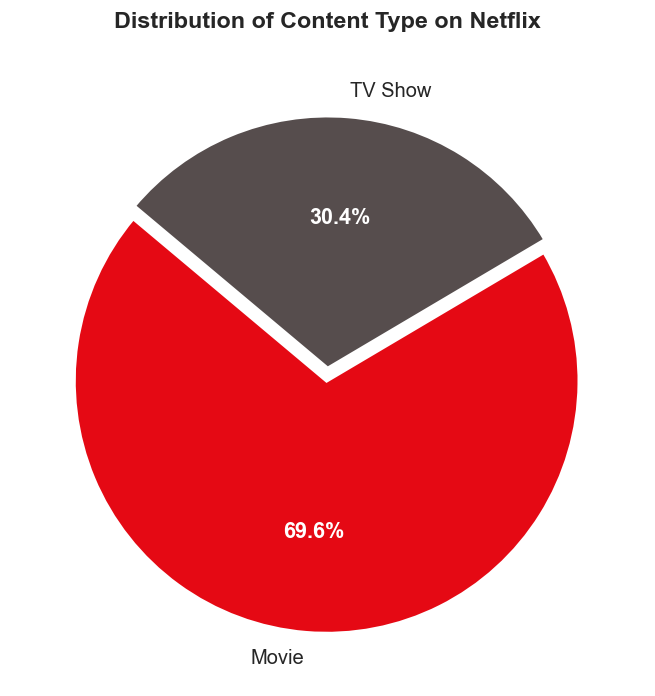


📌 Insight: Movies account for ~70% of Netflix content,
   while TV Shows make up ~30%.


In [6]:
fig, ax = plt.subplots(figsize=(7, 6))

wedges, texts, autotexts = ax.pie(
    type_counts.values,
    labels=type_counts.index,
    autopct='%1.1f%%',
    colors=['#E50914', '#564d4d'],
    startangle=140,
    explode=(0.05, 0),
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)

for text in autotexts:
    text.set_fontsize(13)
    text.set_fontweight('bold')
    text.set_color('white')

ax.set_title('Distribution of Content Type on Netflix',
             fontsize=14, fontweight='bold', pad=15)

plt.tight_layout()
plt.show()

print("\n📌 Insight: Movies account for ~70% of Netflix content,")
print("   while TV Shows make up ~30%.")

**Critical Evaluation:** The pie chart complements the bar chart by showing proportions rather than absolute counts. The exploded slice draws attention to the Movies segment. Percentage labels inside the wedges make it self-explanatory without needing a legend.

---

## Visualization 3 — Line Plot: Content Added to Netflix Over Time

**Purpose:** Show how Netflix expanded its content library year by year.

**Why effective?** A line plot is the best chart for showing trends over time. It clearly shows the growth trajectory and any sharp increases or declines.

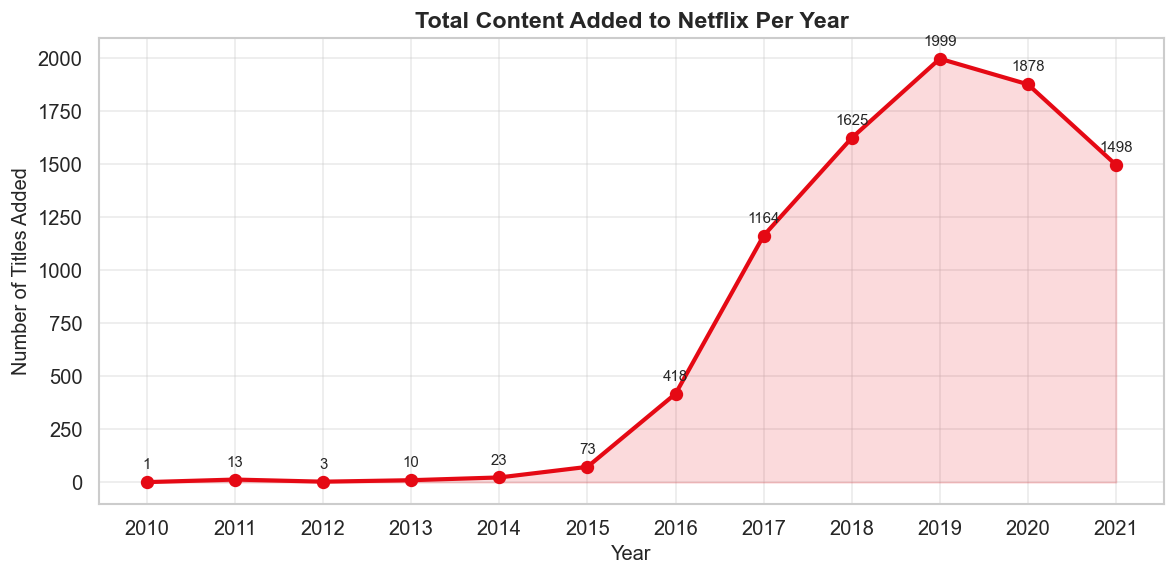


📌 Insight: Netflix content grew rapidly from 2015 onwards,
   peaking around 2019–2020.


In [7]:
content_per_year = df.dropna(subset=['year_added'])\
                     .groupby('year_added').size().reset_index(name='count')
content_per_year = content_per_year[content_per_year['year_added'] >= 2010]

fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(content_per_year['year_added'], content_per_year['count'],
        color='#E50914', linewidth=2.5, marker='o', markersize=7)
ax.fill_between(content_per_year['year_added'], content_per_year['count'],
                alpha=0.15, color='#E50914')

ax.set_title('Total Content Added to Netflix Per Year', fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles Added', fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.grid(True, alpha=0.4)

for _, row in content_per_year.iterrows():
    ax.annotate(f"{int(row['count'])}",
                (row['year_added'], row['count']),
                textcoords='offset points', xytext=(0, 8),
                ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('netflix_content_growth.png', dpi=150)
plt.show()

print("\n📌 Insight: Netflix content grew rapidly from 2015 onwards,")
print("   peaking around 2019–2020.")

**Critical Evaluation:** The filled area under the line adds visual weight and emphasizes cumulative growth. Annotations on each data point make exact values readable. The chart clearly reveals Netflix's aggressive content expansion strategy post-2016.

---

## Visualization 4 — Bar Chart: Top 10 Countries Producing Netflix Content

**Purpose:** Identify which countries contribute the most content to Netflix.

**Why effective?** A horizontal bar chart is ideal for ranked categorical data with long labels. Sorting by value makes the ranking immediately clear.

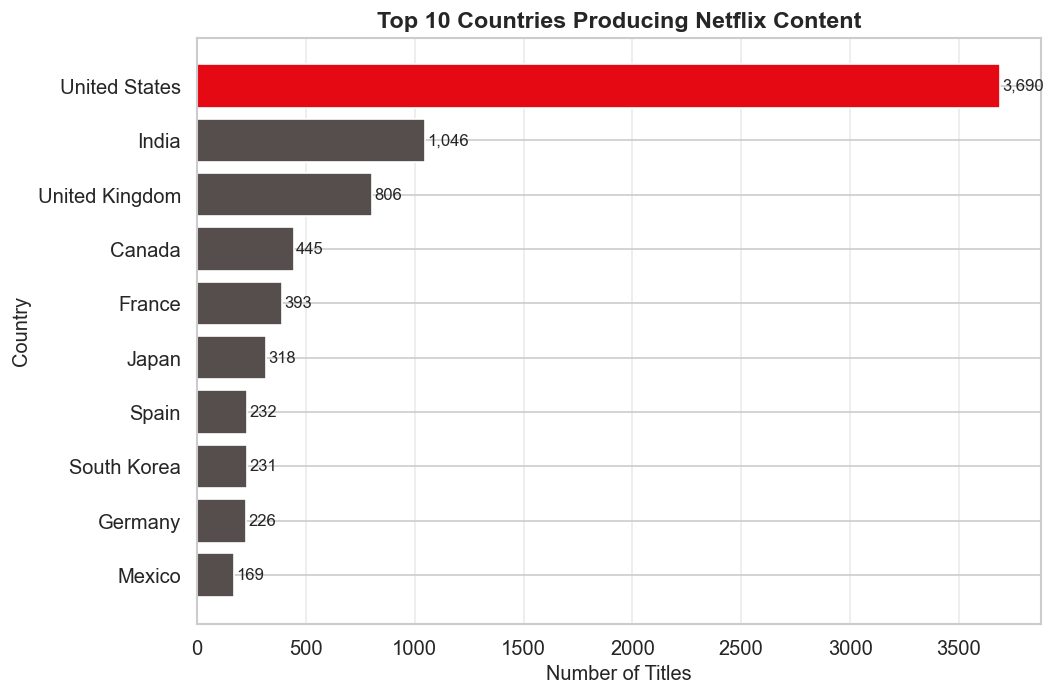


📌 Insight: The United States dominates Netflix content,
   followed by India and the United Kingdom.


In [8]:
top_countries = (
    df['country'].str.split(',')
    .explode()
    .str.strip()
    .replace('Unknown', np.nan)
    .dropna()
    .value_counts()
    .head(10)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 6))
colors = ['#E50914' if i == len(top_countries)-1 else '#564d4d'
          for i in range(len(top_countries))]

bars = ax.barh(top_countries.index, top_countries.values,
               color=colors, edgecolor='white')

ax.set_title('Top 10 Countries Producing Netflix Content', fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=12)
ax.set_ylabel('Country', fontsize=12)
ax.grid(True, axis='x', alpha=0.4)

for bar in bars:
    ax.text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
            f'{int(bar.get_width()):,}', va='center', fontsize=10)

plt.tight_layout()
plt.savefig('netflix_top_countries.png', dpi=150)
plt.show()

print("\n📌 Insight: The United States dominates Netflix content,")
print("   followed by India and the United Kingdom.")

**Critical Evaluation:** A horizontal bar chart works better than a vertical one here because country names are long. The top-ranked country is highlighted in Netflix red to draw the eye. Sorted order makes ranking comparisons effortless.

---

## Visualization 5 — Histogram: Distribution of Release Years

**Purpose:** Understand when the content available on Netflix was originally produced.

**Why effective?** A histogram reveals the frequency distribution of a continuous variable. It shows whether Netflix favors recent or older content.

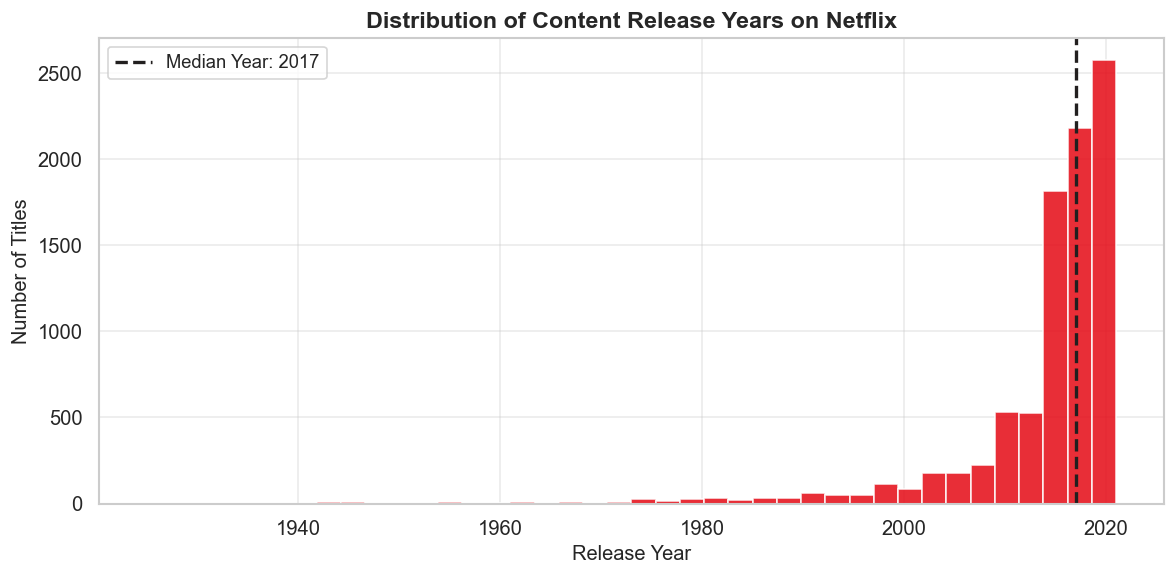


📌 Insight: The vast majority of Netflix content was released
   after 2010, showing a strong preference for recent productions.


In [9]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.hist(df['release_year'], bins=40, color='#E50914',
        edgecolor='white', alpha=0.85)
ax.axvline(df['release_year'].median(), color='#221F1F',
           linestyle='--', linewidth=2,
           label=f'Median Year: {int(df["release_year"].median())}')

ax.set_title('Distribution of Content Release Years on Netflix',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Release Year', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print("\n📌 Insight: The vast majority of Netflix content was released")
print("   after 2010, showing a strong preference for recent productions.")

**Critical Evaluation:** The histogram is the correct choice for continuous year data. The median line provides a reference point that anchors the viewer's understanding of the central tendency. The right-skewed shape reveals Netflix's strong focus on modern content.

---

## Visualization 6 — Count Plot: Ratings Distribution

**Purpose:** Identify the most common content rating categories on Netflix.

**Why effective?** A count plot clearly shows the frequency of each rating category. It reveals Netflix's target audience demographic.

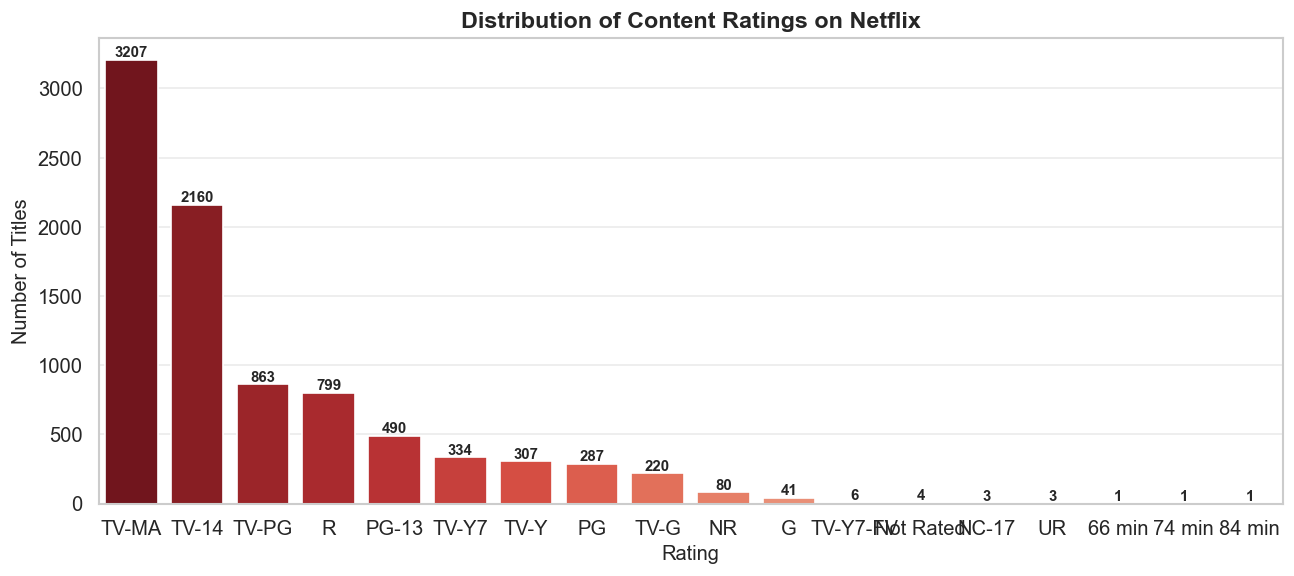


📌 Insight: TV-MA (Mature Audiences) is the most common rating,
   indicating Netflix primarily targets adult viewers.


In [10]:
rating_order = df['rating'].value_counts().index.tolist()

fig, ax = plt.subplots(figsize=(11, 5))

sns.countplot(data=df, x='rating', order=rating_order,
              palette='Reds_r', ax=ax)

ax.set_title('Distribution of Content Ratings on Netflix',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Rating', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.grid(True, axis='y', alpha=0.4)

for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}',
                    (p.get_x() + p.get_width()/2., p.get_height()),
                    ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('netflix_ratings.png', dpi=150)
plt.show()

print("\n📌 Insight: TV-MA (Mature Audiences) is the most common rating,")
print("   indicating Netflix primarily targets adult viewers.")

**Critical Evaluation:** Ordering bars by frequency (descending) makes it immediately obvious which ratings are most common. The Reds color palette visually connects to the Netflix brand. Count annotations eliminate the need to read off the y-axis.

---

## Visualization 7 — Line Plot: Movies vs TV Shows Added Over Time

**Purpose:** Analyze how Netflix's content strategy evolved — did it add more Movies or TV Shows over the years?

**Why effective?** Overlaying two lines on the same axis makes comparison across time direct and intuitive.

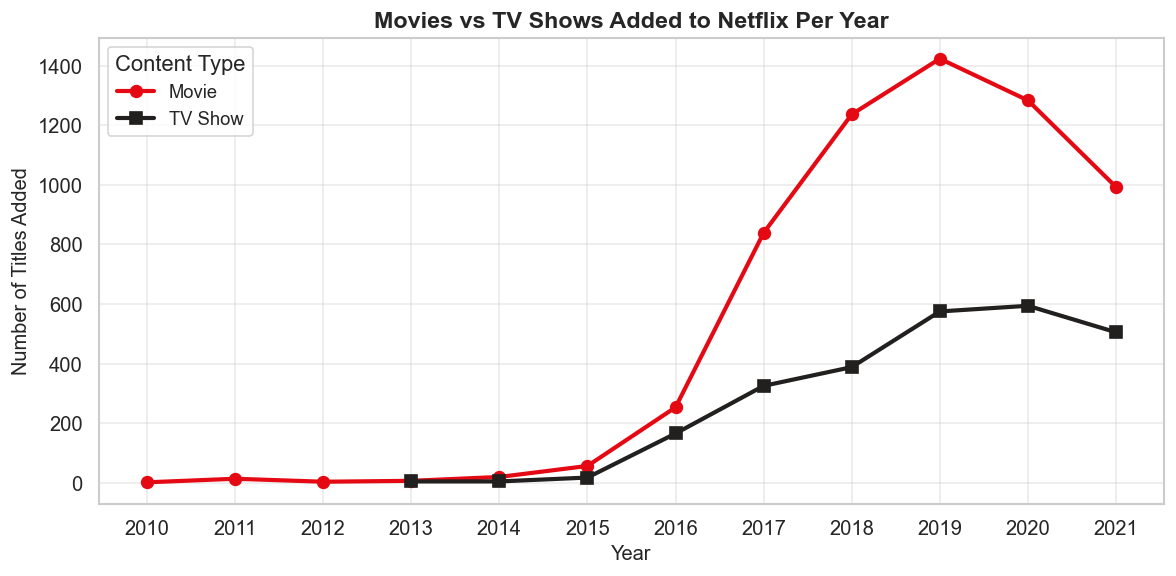


📌 Insight: Movies consistently outnumber TV Shows added each year,
   but TV Show additions grew significantly from 2016 onwards.


In [11]:
type_year = df.dropna(subset=['year_added'])\
              .groupby(['year_added', 'type']).size().reset_index(name='count')
type_year = type_year[type_year['year_added'] >= 2010]

fig, ax = plt.subplots(figsize=(10, 5))

for content_type, color, marker in [('Movie', '#E50914', 'o'), ('TV Show', '#221F1F', 's')]:
    data = type_year[type_year['type'] == content_type]
    ax.plot(data['year_added'], data['count'], color=color,
            linewidth=2.5, marker=marker, markersize=7, label=content_type)

ax.set_title('Movies vs TV Shows Added to Netflix Per Year',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Year', fontsize=12)
ax.set_ylabel('Number of Titles Added', fontsize=12)
ax.xaxis.set_major_locator(mticker.MultipleLocator(1))
ax.legend(title='Content Type', fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print("\n📌 Insight: Movies consistently outnumber TV Shows added each year,")
print("   but TV Show additions grew significantly from 2016 onwards.")

**Critical Evaluation:** Two lines on one plot make it easy to compare how each content type grew over time. The contrasting colors (Netflix red vs dark) clearly differentiate the two series. This reveals Netflix's increasing investment in TV Show originals.

---

## Visualization 8 — Histogram: Movie Duration Distribution

**Purpose:** Understand the typical length of movies on Netflix.

**Why effective?** A histogram with KDE overlay reveals the shape of the duration distribution — whether most movies are short, long, or clustered around a typical runtime.

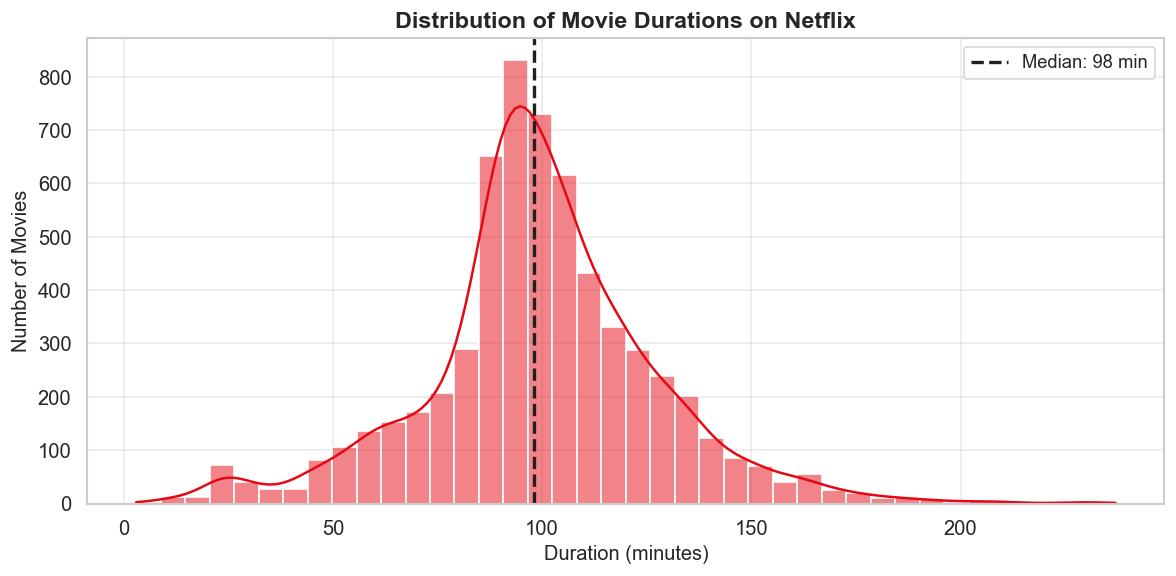


📌 Insight: Most Netflix movies are between 80–120 minutes long.
   Median duration: 98 minutes


In [12]:
movies = df[df['type'] == 'Movie'].dropna(subset=['duration_int'])
movies = movies[movies['duration_int'] < 250]  # Remove extreme outliers

fig, ax = plt.subplots(figsize=(10, 5))

sns.histplot(movies['duration_int'], bins=40, kde=True,
             color='#E50914', ax=ax)
ax.axvline(movies['duration_int'].median(), color='#221F1F',
           linestyle='--', linewidth=2,
           label=f'Median: {int(movies["duration_int"].median())} min')

ax.set_title('Distribution of Movie Durations on Netflix',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Duration (minutes)', fontsize=12)
ax.set_ylabel('Number of Movies', fontsize=12)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.show()

print(f"\n📌 Insight: Most Netflix movies are between 80–120 minutes long.")
print(f"   Median duration: {int(movies['duration_int'].median())} minutes")

**Critical Evaluation:** The KDE curve smooths the histogram to show the overall shape of the distribution clearly. The median line anchors the viewer's sense of the typical movie length. The near-normal distribution peaks around 90–100 minutes — the standard feature film length.

---

## Visualization 9 — Heatmap: Correlation Between Numerical Features

**Purpose:** Identify correlations between numerical variables in the dataset.

**Why effective?** A heatmap gives a quick overview of all pairwise relationships simultaneously — patterns and strong correlations stand out through color intensity.

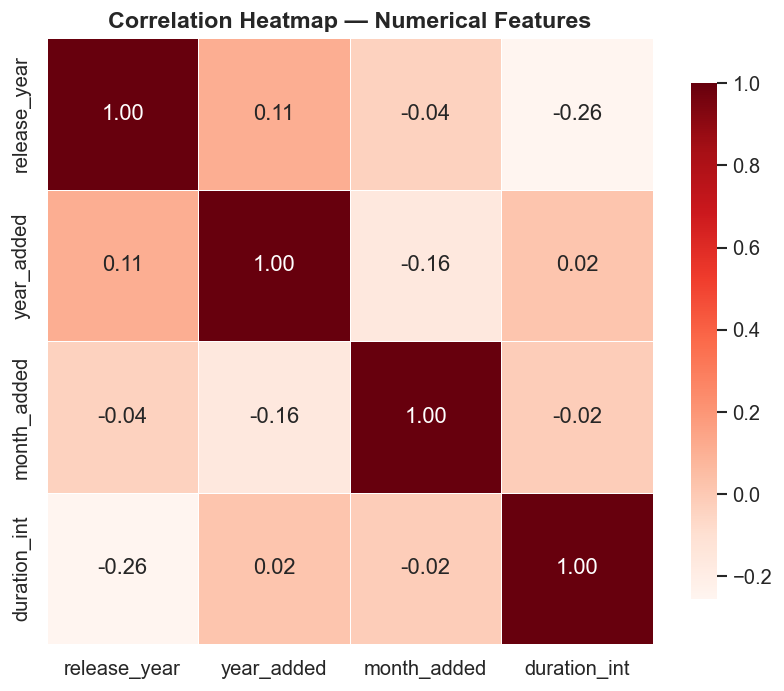


📌 Insight: release_year and year_added are positively correlated —
   Netflix tends to add recently released content to its platform quickly.


In [13]:
num_df = df[['release_year', 'year_added', 'month_added', 'duration_int']].dropna()
corr   = num_df.corr()

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='Reds',
            linewidths=0.5, square=True, ax=ax,
            cbar_kws={'shrink': 0.8})

ax.set_title('Correlation Heatmap — Numerical Features',
             fontsize=14, fontweight='bold')

plt.tight_layout()
plt.savefig('netflix_heatmap.png', dpi=150)
plt.show()

print("\n📌 Insight: release_year and year_added are positively correlated —")
print("   Netflix tends to add recently released content to its platform quickly.")

**Critical Evaluation:** The heatmap is the most efficient way to display multiple correlations at once. Annotation values inside cells eliminate ambiguity. The Reds palette aligns with the Netflix brand while intuitively showing intensity of correlation.

---

## Visualization 10 — Word Cloud: Most Common Genres

**Purpose:** Visually display the most frequently occurring genres across all Netflix titles.

**Why effective?** A word cloud gives an immediate visual impression of dominant themes. Larger words draw attention to the most frequent genres, making patterns visible at a glance.

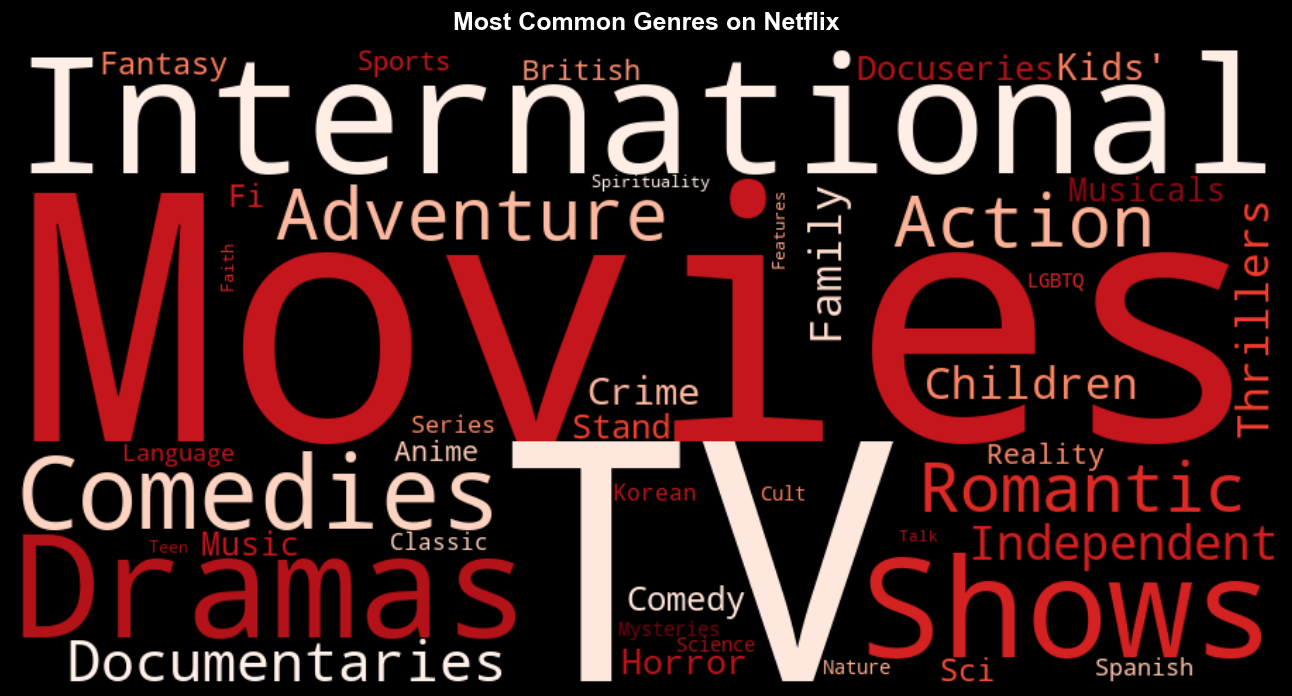


📌 Insight: Dramas, Comedies, and Documentaries are the
   most dominant genres on Netflix.


In [14]:
all_genres = ' '.join(df['listed_in'].dropna().values)

wordcloud = WordCloud(
    width=900, height=450,
    background_color='black',
    colormap='Reds',
    max_words=100,
    collocations=False
).generate(all_genres)

fig, ax = plt.subplots(figsize=(12, 6))
ax.imshow(wordcloud, interpolation='bilinear')
ax.axis('off')
ax.set_title('Most Common Genres on Netflix',
             fontsize=15, fontweight='bold', color='white',
             backgroundcolor='black', pad=12)

fig.patch.set_facecolor('black')
plt.tight_layout()
plt.savefig('netflix_wordcloud.png', dpi=150, facecolor='black')
plt.show()

print("\n📌 Insight: Dramas, Comedies, and Documentaries are the")
print("   most dominant genres on Netflix.")

**Critical Evaluation:** A word cloud is uniquely suited for showing text frequency data in a visually engaging way. The black background with red tones matches the Netflix aesthetic. The size hierarchy makes the dominant genres immediately identifiable without reading every word.

---

## Visualization 11 — Bar Chart: Top 15 Directors on Netflix

**Purpose:** Identify which directors have the most titles on Netflix.

**Why effective?** A sorted horizontal bar chart makes rankings easy to read. Directors with multiple titles suggest strong partnerships with Netflix.

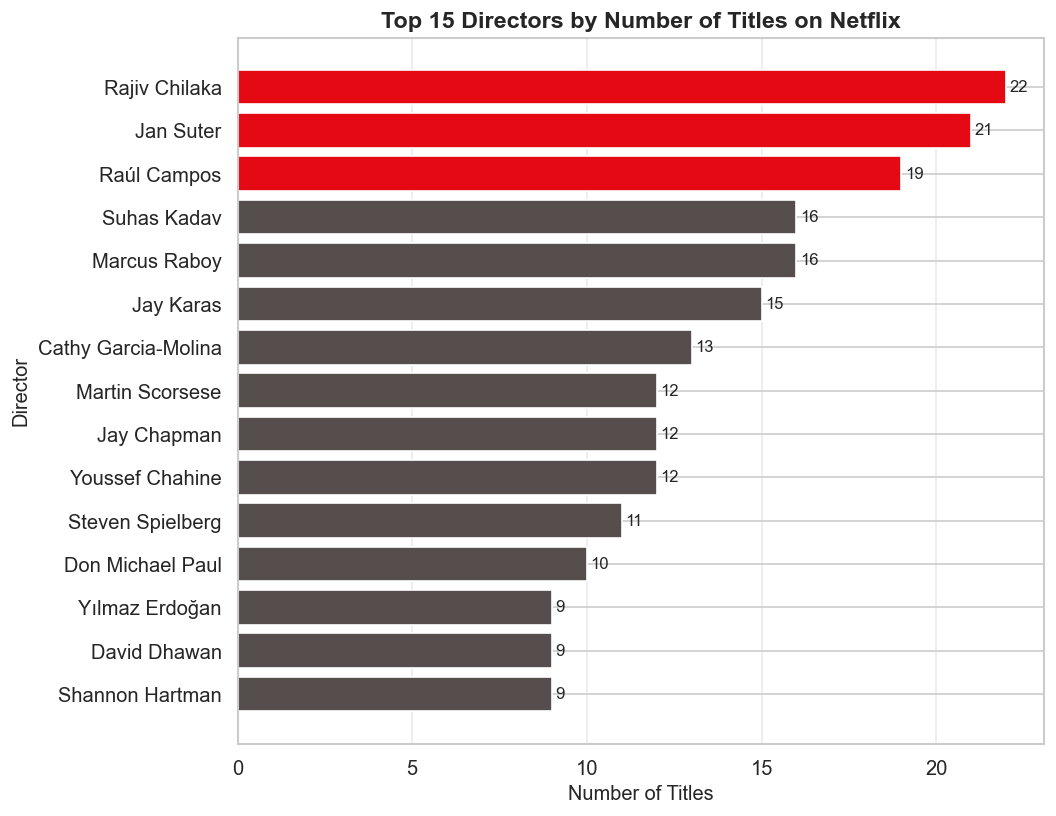


📌 Insight: A small number of prolific directors dominate Netflix content,
   many specializing in documentaries and international films.


In [15]:
top_directors = (
    df[df['director'] != 'Unknown']['director']
    .str.split(',')
    .explode()
    .str.strip()
    .value_counts()
    .head(15)
    .sort_values()
)

fig, ax = plt.subplots(figsize=(9, 7))
colors = ['#E50914' if i >= len(top_directors)-3 else '#564d4d'
          for i in range(len(top_directors))]

bars = ax.barh(top_directors.index, top_directors.values,
               color=colors, edgecolor='white')

ax.set_title('Top 15 Directors by Number of Titles on Netflix',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Number of Titles', fontsize=12)
ax.set_ylabel('Director', fontsize=12)
ax.grid(True, axis='x', alpha=0.4)

for bar in bars:
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height()/2,
            str(int(bar.get_width())), va='center', fontsize=10)

plt.tight_layout()
plt.show()

print("\n📌 Insight: A small number of prolific directors dominate Netflix content,")
print("   many specializing in documentaries and international films.")

**Critical Evaluation:** The top 3 directors are highlighted in Netflix red to distinguish the leaders from the rest. Horizontal layout accommodates long director names without rotation. The sorted order makes the ranking immediately readable.

---

## Visualization 12 — Stacked Bar Chart: Content Added by Month

**Purpose:** Discover whether Netflix follows seasonal patterns when adding content.

**Why effective?** A stacked bar chart shows both total volume and the Movies vs TV Shows breakdown for each month in one view.

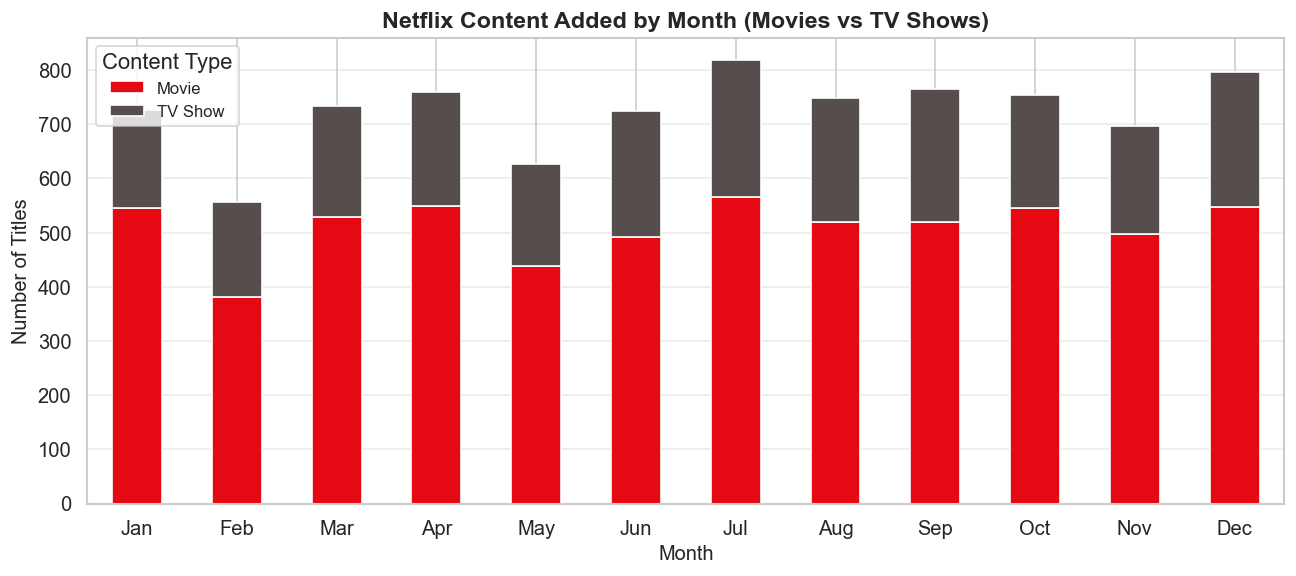


📌 Insight: Netflix adds the most content in January and July,
   suggesting seasonal content pushes at the start of each half-year.


In [16]:
month_type = df.dropna(subset=['month_added'])\
               .groupby(['month_added', 'type']).size().unstack(fill_value=0)

month_names = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']
month_type.index = [month_names[int(i)-1] for i in month_type.index]

fig, ax = plt.subplots(figsize=(11, 5))
month_type.plot(kind='bar', stacked=True, ax=ax,
                color=['#E50914', '#564d4d'], edgecolor='white')

ax.set_title('Netflix Content Added by Month (Movies vs TV Shows)',
             fontsize=14, fontweight='bold')
ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Number of Titles', fontsize=12)
ax.legend(title='Content Type', fontsize=10)
ax.grid(True, axis='y', alpha=0.4)
plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

print("\n📌 Insight: Netflix adds the most content in January and July,")
print("   suggesting seasonal content pushes at the start of each half-year.")

**Critical Evaluation:** A stacked bar chart is ideal here as it simultaneously shows total additions per month AND the breakdown between content types. The monthly view reveals Netflix's content release calendar strategy.

---

## Key Insights

- **Movies dominate** — Netflix has ~70% movies and ~30% TV shows
- **USA leads** content production, followed by India and the UK
- **Explosive growth** — Netflix content additions surged from 2015 onwards, peaking around 2019
- **Adult-focused** — TV-MA is the most common rating, targeting mature audiences
- **Recent content** — Most titles were released after 2010, showing preference for modern productions
- **Standard movie length** — Most movies run between 80–120 minutes
- **Dramas and Comedies** are the most common genres across the platform
- **Seasonal patterns** — More content is added at the start of each half-year (Jan, Jul)
- **TV Shows growing** — While movies dominate, TV Show additions grew significantly after 2016

---

## Conclusion

This analysis of the Netflix dataset reveals several clear trends:

- Netflix is primarily a **movie platform** but is increasingly investing in TV shows and original series
- The platform experienced **explosive growth between 2015 and 2019**, reflecting its global expansion strategy
- Content is **heavily skewed toward mature audiences** (TV-MA, R ratings), suggesting Netflix targets adults as its core demographic
- The **United States dominates** content production, but India and the UK are strong second and third contributors, reflecting Netflix's international strategy
- **Dramas and Comedies** remain the platform's content backbone, supported by a growing library of Documentaries and International titles
- The strong correlation between `release_year` and `year_added` shows Netflix **adds recent content quickly**, keeping its library fresh

